# How to load modes from a FELiCS run and compute structural sensitivity

Before you start, you should install all necessary FELiCS packages, and install FELiCS as a package itself. The [installation guide](https://felics-d43476.gitlab.io/installation_guide.html) explains those steps in detail. After installing FELiCS you can start writing your first FELiCS script.

--- 
## Description

This tutorial describes the structural sensitivity analysis of the leading global mode of the 2D cylinder wake.

In this turorial, we will:
- Load the leading direct and adjoint modes using the FELiCS I/O modules,
- Normalize them consistently,
- Compute the wavemaker field,
- Compare with the result from [Giannetti & Luchini (2007)](https://doi.org/10.1017/S0022112007005654).

For this tutorial, we use pre-computed results from the stability analysis for the cylinder flow. These results are saved in the [input/](./Input/) directory. The stability analysis included the computation of both direct and adjoint modes.

Here $Re=\frac{u_\infty D}{\nu}=50$, with $u_\infty$ the freestream velocity, $D$ the diameter of the cylinder, and $\nu$ the molecular (kinematic) flow viscosity.



---
## Loading FELiCS results

We start by loading the pre-computed stability results as FELiCS *mode objects*.

This allows us to:
- Inspect the modes directly within FELiCS (instead of only visualizing them in ParaView),
- Evaluate expressions involving the mode shapes, such as the structural sensitivity.

---
### Reconstructing the FEM context

The saved mode files contain the degrees of freedom of the eigenvectors.  
To interpret them as finite-element fields, we must reconstruct the same mesh and function spaces that were used during the stability computation.

We begin by loading the necessary FELiCS modules, as well as the `ufl` package, which allows us to define and evaluate finite-element expressions.

In [1]:
# Set the environment variable OMP_NUM_THREADS
%env OMP_NUM_THREADS=1

# Load FELiCS modules
from    FELiCS.Parameters.Config            import  Config
from    FELiCS.Misc.logging                 import  Logger
from    FELiCS.IO.Reader                    import  Reader
from    FELiCS.Fields.Field                 import  Field
from    FELiCS.IO.Writer                    import  Writer
from    FELiCS.SpaceDisc.FEMSpaces          import  FEMSpaces
from    FELiCS.Fields.ModeCollection        import  ModeCollection
from    FELiCS.Misc.tensorUtils             import  Tensor, i_dot, i_conj
from    FELiCS.Equation.UflDecorator        import  UflDecorator

# Load 3rd party modules
import  ufl

env: OMP_NUM_THREADS=1
(         (               (     
)\ )      ) )       (    )\ )  
(()/(  (  (()/( (    )\   (()/(  
/(_)) )\  /(_)))\  (((_)  /(_)) 
(_)_)((_) (_)) ((_) )\___ (_))   
| __|| __|| |   (_)((/ __|/ __|  
| _| | _| | |__ | | | (__ \__ \  
|_|  |___||____||_|  \___||___/  
Git commit: 


fatal: not a git repository: '/home/demange/anaconda3/envs/felics/lib/python3.13/site-packages/../.git'


🔧 **Reconstruct the FELiCS objects**  

We now rebuild the FELiCS objects needed for the sensitivity analysis. These are created using the same **configuration file** that was used for the modal stability analysis.

*This ensures that the mesh, finite-element spaces, and physical parameters are identical to those used when computing the eigenmodes.*

In [2]:
# Get the logger for nice printout messages
logger      = Logger(True, False, "felics")
logger      = Logger.get_logger("felics")

# Load the configuration file that was used for the stability analysis. 
param       = Config()
param.import_from_file("Input/config.json")

# We get the mesh object
mesh        = param.get_mesh()

# The FEM spaces used for the stability analysis
FEMSpaces   = FEMSpaces(param, mesh)

Debug    | logging.py             | _setup_logger              (line 245 ) : Logger initialized successfully
Debug    | Config.py              | __init__                   (line 68  ) : Initializing config class with defaults.
Info     | Config.py              | import_from_file           (line 245 ) : Loading configuration from Input/config.json
Warning  | Config.py              | import_from_file           (line 264 ) : Field "MolViscPerturbModel" missing from file, setting default: {'type': 'Constant', 'Constants': {'Viscosity': 1.0}}
Warning  | Config.py              | import_from_file           (line 264 ) : Field "PrandtlNumber" missing from file, setting default: 0.72
Warning  | Config.py              | import_from_file           (line 264 ) : Field "Video" missing from file, setting default: False
Warning  | Config.py              | import_from_file           (line 264 ) : Field "ForcingNorm" missing from file, setting default: TKE
Warning  | Config.py              | import_fro

📥 **Initialize the Reader**

We now create a `reader` object to load the saved mode data into FELiCS.

In [3]:
reader = Reader(
    sourceDir           = "Input",
    needInterpolation   = False,
)

---
### Loading FELiCS modes

We first create an empty FELiCS `ModeCollection`. This object is used to manage groups of modes (eigenvalues and corresponding mode shapes), facilitates filtering, and provides utility functions (descriptions, sorting, exporting, etc.).

By providing the `reader` to this collection, we can load all FELiCS modes saved in the 'results/' directory.

In [4]:
# Create empty mode collection to import into
importSolution  = ModeCollection(
    FEMSpaces.VMixed,
    mesh
)

# Load all the modes from the reader source directory into the mode collection
importSolution.import_data(
    reader,
)

Info     | ModeCollection.py      | import_data                (line 1047) : 20 modes to import into mode collection.
Info     | ModeCollection.py      | import_data                (line 1049) : Importing mode 1/20 from file "Mode_Modal_Direct_Omega_0.751-0.099j.h5".
Debug    | Reader.py              | _update_calc_mesh          (line 459 ) : New calculation mesh / FEM space type, updating cache.
Debug    | Reader.py              | clear_cached_properties    (line 561 ) : No cached properties to clear.
Debug    | Reader.py              | import_mesh_coords         (line 267 ) : Associating import mesh to Reader instance.
Debug    | Reader.py              | import_mesh_coords         (line 272 ) : Getting the 2D import mesh coordinates (['x', 'y']).
Debug    | Reader.py              | import_mesh_coords         (line 335 ) : Executing Option 3: No interpolation needed: load from FELiCS exported mesh file.
Debug    | Reader.py              | import_mesh_coords         (line 346 ) : self.

🔍 **Inspect the loaded modes**

We can look at the results we just loaded by:
1. Examining the spectrum
2. Isolating and plotting the leading modes (adjoint and direct) shape 


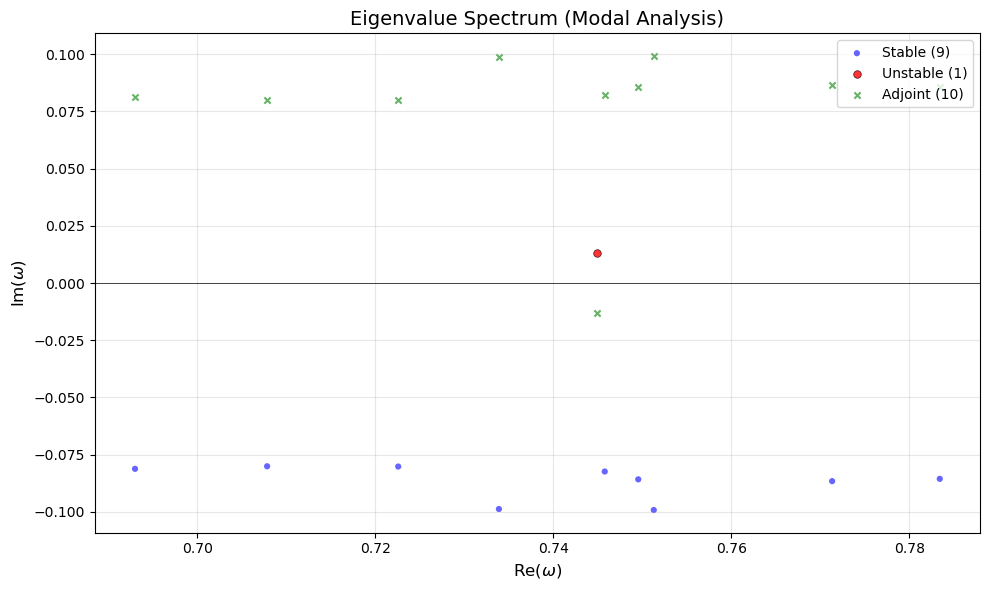

In [5]:
# Plotting the spectrum
ax = importSolution.plot_spectrum()

Text(0.5, 1.0, 'Leading adjoint mode shape')

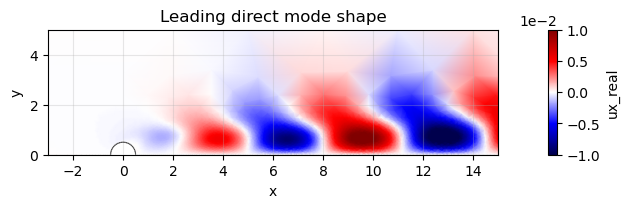

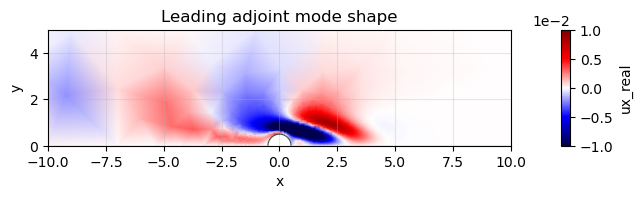

In [6]:
# Get the leading eigenvalue and eigenvector
leading_mode_direct    = importSolution.get_leading_mode()

# Similarly, we can get the leading adjoint mode
leading_mode_adjoint   = importSolution.get_leading_mode(adjoint = True)

# Plot the leading mode shape
ax = leading_mode_direct.plot(
    'ux', 
    xlim = (-3, 15), 
    ylim = (0, 5), 
    clim = (-1e-2, 1e-2)
)
ax.set_title("Leading direct mode shape")

# Plot the leading adjoint mode shape
ax = leading_mode_adjoint.plot(
    'ux', 
    xlim = (-10, 10), 
    ylim = (0, 5), 
    clim = (-1e-2, 1e-2)
)
ax.set_title("Leading adjoint mode shape")

Note the spatial distribution of the direct and adjoint leading modes:

- The direct mode exhibits strong fluctuations in the near wake, downstream of the cylinder.
- The adjoint mode is concentrated upstream of the cylinder and along the shear layers, wrapping around the solid surface.

The structural sensitivity measures the local overlap between these two fields.

---
## Sensitivity analysis

### Reminder

For the generalized eigenproblem

$$\mathbf{A} \hat{q} = \lambda \mathbf{B} \hat{q},$$

the structural sensitivity tensor is defined as

$$\mathbf{S}(x)=\hat{q}(x)\otimes \hat{q}^\dagger(x)^*.$$

With its Frobenius norm

$$S(x)=\|\mathbf{S}(x)\|_F
= \|\hat{u}(x)\|\,\|\hat{u}^\dagger(x)\|,$$

representing the *maximum possible local eigenvalue variation* for a unit-norm localized feedback at position $x$.

For an incompressible flow, the typical state vector is $\hat{q} = [\hat{u}, \hat{p}]$ (see [config.json](./Input/config.json)).
However, the pressure acts solely as a Lagrange multiplier to enforce the divergence-free constraint on the velocity vector. Thus its time evolution does not appear explicitely in the equations, and **only the velocity fluctuations are considered when computing the sensitivity**.

Additionaly, the expression for the structural sensitivity above assumes the following **bi-orthogonality normalization**:
$$
⟨\hat{u}^{\dagger}, \hat{u}⟩
= \int_\Omega \hat{u}^{\dagger *} \cdot \hat{u} \, d\Omega
= 1.
$$

---
### Coding

The next steps are:

1. Extract the velocity component from the full leading mode,
2. Impose the bi-orthogonality normalization (not enforced by default in FELiCS),
3. Compute the sensitivity field using a scalar test function and FELiCS `Field` capabilities,
4. Check the results

🔬 FELiCS organizes the mixed state vector hierarchically:
```text
Mode
 └── Velocity field (u)
    └── Streamwise component (ux)
    └── Transverse component (uy)
 └── Pressure (p)
```

Let us now isolate the velocity components of the modes:

In [7]:
u_direct   = leading_mode_direct.get_list_of_sub_fields()[0]
u_adjoint  = leading_mode_adjoint.get_list_of_sub_fields()[0]

---
### Note on bi-orthogonality condition

To enforce the bi-orthogonality condition, we assemble the overlap scalar

$$
c = ⟨\hat{u}^{\dagger}, \hat{u}⟩
= \int_{\Omega_{1/2}} \hat{u}^{\dagger *} \cdot \hat{u}\, d\Omega,
$$

and divide the direct velocity mode by this constant.

**Half-domain normalization**

The computation is performed on a **half-cylinder domain** using symmetry.

Since the normalization involves a domain integral, restricting the domain changes the absolute scaling of the modes by a factor. In particular,

$$
\int_{\Omega_{1/2}} (\cdot)\, d\Omega
\approx \tfrac12 \int_{\Omega} (\cdot)\, d\Omega.
$$

To enable comparison with full-domain results from the literature, we multiply the normalization constant by a factor 2.

This affects only the absolute amplitude of the sensitivity field; the spatial distribution remains unchanged.

In [8]:
# Get the coordinate system Jacobian determinant for ufl integration
J_hat                   = mesh.coordinate_system.J_hat

# Prepare a UFL decorator to compute the overlap integral
overlap                 = UflDecorator()
overlap                 += (i_dot(u_direct.get_tensor(), i_conj(u_adjoint.get_tensor()))).ufl_tens * J_hat * ufl.dx  # scalar integrand

# Compute the overlap integral (complex scalar) and apply to the direct mode
c                       = 2*overlap.get_assembled_scalar(mesh)      # complex scalar + half-domain contribution
u_direct                = u_direct / c                              # scale direct by 1/c

logger.info(f"Overlap integral: {c.real:.5e} + {c.imag:.5e}j")

Info     | 3798440686.py          | <module>                   (line 12  ) : Overlap integral: 1.99724e-04 + -2.68705e-04j


---
### Computing the sensitivity
We create an empty FELiCS `Field` to store the structural sensitivity.

`Field` objects allow us to evaluate finite-element expressions and export the resulting function values.

In [9]:
# Get the FELiCS function space for a scalar field (P2 in this case) - the structural sensitivity is a scalar field defined on the same mesh as the modes
V_scalar                = FEMSpaces.P2

# Create a field to store the structural sensitivity distribution
sS                      = Field(V_scalar, mesh)
sS.name                 = "StructuralSensitivity"


We now use the ```evaluate_ufl_tensor_expression``` FELiCS routine to **evaluates tensor-based UFL expression** and store the results in a `Field`. It provides a useful way to compute derived quantities (e.g. structural sensitivity, vorticity, energy norms) from fields. 

The method:
- uses the `Tensor` wrapper to ensure correct coordinate-system transformations
- builds the appropriate “mass-like” variational form for the field’s function space
- assembles the form once, and stores the corresponding LU solver for reuse

In [10]:
# Prepare a few objects that we will need to define the symbolic expression of the structural sensitivity
v                       = ufl.TestFunction(V_scalar)
v_tens                  = Tensor(
    v, 
    CoordSys            = sS.mesh.coordinate_system, 
    m                   = sS.m, 
    mayHaveSpectralDimension = sS.hasSpectralDimension
)

# Let's now define the symbolic expression of the structural sensitivity
expression              = (
    i_dot(u_direct.get_tensor(), i_conj(u_direct.get_tensor()))**0.5
    *
    i_dot(u_adjoint.get_tensor(), i_conj(u_adjoint.get_tensor()))**0.5
    * i_conj(v_tens)
).ufl_tens * J_hat* ufl.dx

# We finally pass the expression to the field, which will evaluate it and store the result
sS.evaluate_ufl_tensor_expression(expression)

We can now visualize the structural sensitivity field:

Text(0.5, 1.0, 'Structural sensitivity norm')

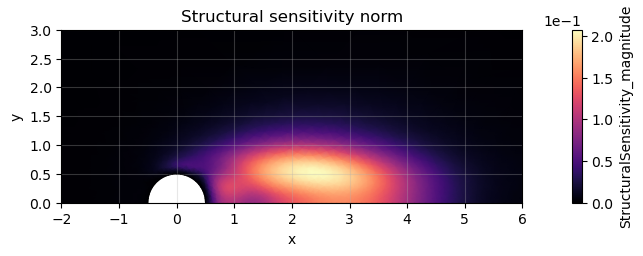

In [11]:
# Plot the structural sensitivity
ax = sS.plot(xlim=(-2, 6), ylim=(0, 3), plotType="magnitude")
ax.set_title("Structural sensitivity norm")

We can also save the results in a file that can be opened in Paraview:

In [12]:
# Save to file using a FELiCS writer object
writer = Writer(exportDir = "results")
sS.export_to_h5(writer, "sensitivity")